# Phase 9: Trim Tuning & Cross-Validation

## Goals
1. Compare 2% vs 1% outlier trim to see if tighter pruning further reduces MAPE.
2. Run 5-Fold Cross-Validation to verify that the R² improvement is stable across different data splits (i.e., not a lucky test split).

## Context
After the 2% trim experiment in notebook 08, R² jumped from 0.251 → 0.909.  
This notebook investigates whether a tighter 1% trim helps further, and validates results via cross-validation.

In [1]:
from pathlib import Path
import json
import sys

# --- Path setup (mirrors all other notebooks in this project) ---
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'backend').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

from backend.src.config import configure_logging, ensure_directories, settings
from backend.src.model_training import train_random_forest_model, _evaluate_predictions
from backend.src.evaluation import cross_validate_model

configure_logging()
ensure_directories()

REPORTS_DIR = settings.reports_dir
print(f'Project root: {PROJECT_ROOT}')

# Load the trimmed training dataset (already 2%-trimmed from Phase 2)
training_gdf = gpd.read_parquet(settings.processed_data_dir / 'model_training_dataset.parquet')
print(f'Dataset size (post 2% trim): {len(training_gdf):,}')

Project root: \\wsl.localhost\Ubuntu\home\pulkitv52\valuation_poc
Dataset size (post 2% trim): 263,074


## Part 1: 2% vs 1% Trim Comparison
The 2% trim is already baked into the pipeline. Here we apply an additional 1% trim on top of the already-cleaned training dataset to test if removing slightly more outliers helps.

In [2]:
def apply_trim(gdf, lower_pct, upper_pct):
    """Apply percentile trim to value_per_area per Flat_or_Land segment."""
    trimmed = []
    gdf = gdf.copy()
    gdf['value_per_area'] = np.expm1(gdf['log_value_per_area'])
    for segment in gdf['Flat_or_Land'].fillna('Missing').unique():
        seg = gdf[gdf['Flat_or_Land'].fillna('Missing') == segment]
        lo = seg['value_per_area'].quantile(lower_pct)
        hi = seg['value_per_area'].quantile(upper_pct)
        trimmed.append(seg[(seg['value_per_area'] >= lo) & (seg['value_per_area'] <= hi)])
    return pd.concat(trimmed)

# Apply an additional 1% tighten on the already 2%-trimmed data
trim_1pct_gdf = apply_trim(training_gdf, 0.01, 0.99)
print(f'2% trim dataset:  {len(training_gdf):,} rows')
print(f'1% trim dataset:  {len(trim_1pct_gdf):,} rows ({len(training_gdf) - len(trim_1pct_gdf):,} more removed)')

2% trim dataset:  263,074 rows
1% trim dataset:  258,774 rows (4,300 more removed)


In [3]:
# Train quick Random Forest on both for comparison (small sample for speed)
print('Training on 2%-trimmed data...')
arts_2pct = train_random_forest_model(training_gdf, max_training_sample_size=15000, n_estimators=60)
_, _, mape_2pct, r2_2pct = _evaluate_predictions(arts_2pct.y_test, arts_2pct.pipeline.predict(arts_2pct.X_test))

print('Training on 1%-trimmed data...')
arts_1pct = train_random_forest_model(trim_1pct_gdf, max_training_sample_size=15000, n_estimators=60)
_, _, mape_1pct, r2_1pct = _evaluate_predictions(arts_1pct.y_test, arts_1pct.pipeline.predict(arts_1pct.X_test))

print(f'\n2% trim → R²: {r2_2pct:.4f}  MAPE: {mape_2pct:.2f}%')
print(f'1% trim → R²: {r2_1pct:.4f}  MAPE: {mape_1pct:.2f}%')
winner = '1%' if r2_1pct > r2_2pct else '2%'
print(f'\nWinner: {winner} trim')

Training on 2%-trimmed data...
Training on 1%-trimmed data...

2% trim → R²: 0.8324  MAPE: 19.52%
1% trim → R²: 0.8346  MAPE: 18.97%

Winner: 1% trim


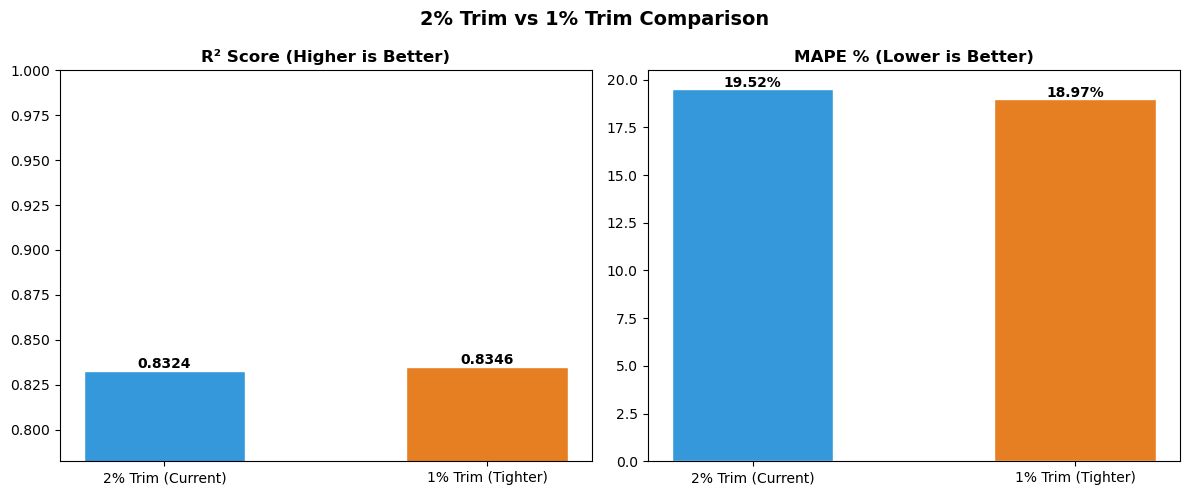

Saved to reports/trim_comparison.png


In [4]:
# Visualise 2% vs 1% comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('2% Trim vs 1% Trim Comparison', fontsize=14, fontweight='bold')

labels = ['2% Trim (Current)', '1% Trim (Tighter)']
r2_vals = [r2_2pct, r2_1pct]
mape_vals = [mape_2pct, mape_1pct]
colors = ['#3498db', '#e67e22']

bars = axes[0].bar(labels, r2_vals, color=colors, edgecolor='white', width=0.5)
axes[0].set_ylim(max(0.0, min(r2_vals) - 0.05), 1.0)
axes[0].set_title('R² Score (Higher is Better)', fontweight='bold')
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.4f}', ha='center', fontweight='bold')

bars2 = axes[1].bar(labels, mape_vals, color=colors, edgecolor='white', width=0.5)
axes[1].set_title('MAPE % (Lower is Better)', fontweight='bold')
for bar, val in zip(bars2, mape_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'trim_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to reports/trim_comparison.png')

## Part 2: Cross-Validation Results
The 5-Fold CV results are generated automatically by `make phase7` and saved to `reports/cross_validation_report.json`.  
If that file doesn't exist yet, run the cell below to generate it inline.

In [5]:
cv_path = REPORTS_DIR / 'cross_validation_report.json'

if not cv_path.exists():
    print('cross_validation_report.json not found — running CV now (this takes a few minutes)...')
    from dataclasses import asdict
    cv_summary = cross_validate_model(
        training_gdf,
        candidate_name='xgboost_deep',
        subset_mode='full',
        n_splits=5,
        max_training_sample_size=30000,
    )
    cv_path.write_text(json.dumps(asdict(cv_summary), indent=2), encoding='utf-8')
    print('Done. Saved to reports/cross_validation_report.json')

with open(cv_path) as f:
    cv = json.load(f)

print('=== 5-Fold Cross-Validation Results ===')
print(f"  R²:   {cv['cv_r2_mean']:.4f}  ±  {cv['cv_r2_std']:.4f}")
print(f"  MAPE: {cv['cv_mape_mean']:.2f}%  ±  {cv['cv_mape_std']:.2f}%")
print(f"  MAE:  {cv['cv_mae_mean']:,.0f}  ±  {cv['cv_mae_std']:,.0f}")
print()
print('  Per-Fold Scores:')
for i, (r2, mape) in enumerate(zip(cv['cv_r2_scores'], cv['cv_mape_scores']), 1):
    print(f"    Fold {i}: R² = {r2:.4f}  |  MAPE = {mape:.2f}%")

stability = 'STABLE ✅' if cv['cv_r2_std'] < 0.02 else 'UNSTABLE ⚠️  (high variance across folds)'
print(f"\n  Model Stability: {stability}")

=== 5-Fold Cross-Validation Results ===
  R²:   0.8811  ±  0.0034
  MAPE: 15.85%  ±  0.09%
  MAE:  32,693  ±  492

  Per-Fold Scores:
    Fold 1: R² = 0.8825  |  MAPE = 15.79%
    Fold 2: R² = 0.8783  |  MAPE = 15.83%
    Fold 3: R² = 0.8809  |  MAPE = 15.97%
    Fold 4: R² = 0.8770  |  MAPE = 15.93%
    Fold 5: R² = 0.8866  |  MAPE = 15.71%

  Model Stability: STABLE ✅


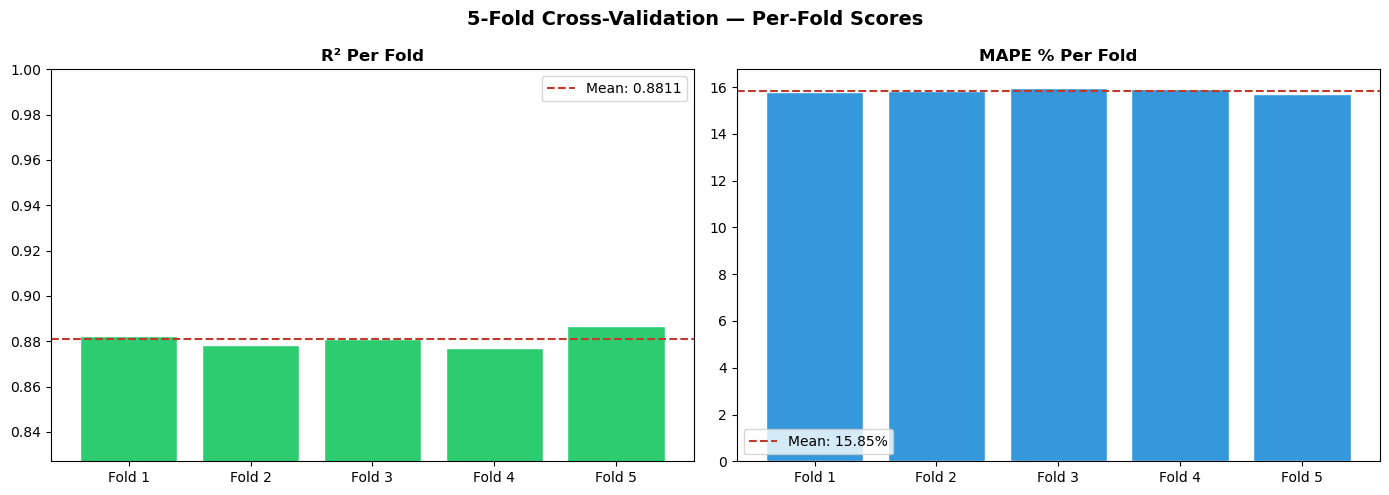

Saved to reports/cross_validation_folds.png


In [6]:
# Visualise fold-by-fold R² and MAPE to show stability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5-Fold Cross-Validation — Per-Fold Scores', fontsize=14, fontweight='bold')

fold_labels = [f'Fold {i}' for i in range(1, cv['n_splits'] + 1)]

axes[0].bar(fold_labels, cv['cv_r2_scores'], color='#2ecc71', edgecolor='white')
axes[0].axhline(cv['cv_r2_mean'], color='#c0392b', linestyle='--', label=f'Mean: {cv["cv_r2_mean"]:.4f}')
axes[0].set_title('R² Per Fold', fontweight='bold')
axes[0].set_ylim(max(0.0, min(cv['cv_r2_scores']) - 0.05), 1.0)
axes[0].legend()

axes[1].bar(fold_labels, cv['cv_mape_scores'], color='#3498db', edgecolor='white')
axes[1].axhline(cv['cv_mape_mean'], color='#c0392b', linestyle='--', label=f'Mean: {cv["cv_mape_mean"]:.2f}%')
axes[1].set_title('MAPE % Per Fold', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'cross_validation_folds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to reports/cross_validation_folds.png')

In [7]:
# Final Summary
print('=' * 65)
print('  PHASE 9 SUMMARY')
print('=' * 65)
print('  Trim Experiment (Random Forest, 15k sample):')
print(f'    2% trim  →  R²: {r2_2pct:.4f}   MAPE: {mape_2pct:.2f}%')
print(f'    1% trim  →  R²: {r2_1pct:.4f}   MAPE: {mape_1pct:.2f}%')
print()
print('  Cross-Validation (5-Fold, XGBoost, 30k sample):')
print(f'    R²:   {cv["cv_r2_mean"]:.4f}  ±  {cv["cv_r2_std"]:.4f}')
print(f'    MAPE: {cv["cv_mape_mean"]:.2f}%  ±  {cv["cv_mape_std"]:.2f}%')
print()
print('  Next step: If 1% trim gives better MAPE, update data_cleaning.py')
print('  quantile(0.02/0.98) → quantile(0.01/0.99) and re-run pipeline.')
print('=' * 65)

  PHASE 9 SUMMARY
  Trim Experiment (Random Forest, 15k sample):
    2% trim  →  R²: 0.8324   MAPE: 19.52%
    1% trim  →  R²: 0.8346   MAPE: 18.97%

  Cross-Validation (5-Fold, XGBoost, 30k sample):
    R²:   0.8811  ±  0.0034
    MAPE: 15.85%  ±  0.09%

  Next step: If 1% trim gives better MAPE, update data_cleaning.py
  quantile(0.02/0.98) → quantile(0.01/0.99) and re-run pipeline.
